# **Model Output Unit Testing**

imports

In [ ]:
import pandas as pd
import numpy as np 
import data.data_to_sql as data_to_sql
from data.unit_tests import CheckWeights
import matplotlib.pyplot as plt 

## Model Weight Analysis

In [ ]:
# get dataframe 
def query_sql_database(tickers: list[str], file_name: str, database_name: str) -> pd.DataFrame:
    db = data_to_sql.CreateSQLiteDatabase(tickers, file_name, database_name)
    db.create_access_database_file()
    data = db.query_database()
    data['index'] = pd.to_datetime(arg = data['index'])
    data.set_index(keys = 'index', inplace = True)
    return data 

# tickers 
tickers = ['BTC-GBP', 'ETH-GBP', 'SOL-GBP', 'ADA-GBP']
# query databases
w_p = query_sql_database(tickers, 'model_output.db', 'model_output')
w_a = query_sql_database(tickers, 'real_invested_weights.db', 'real_invested_weights')

# arrays 
w_p_ary = np.array(w_p, dtype = np.float64)
w_a_ary = np.array(w_a, dtype = np.float64)

# print
print(f'target portfolio weights:\n {w_p}\n \nactual portfolio weights:\n {w_a}')

,BTC-GBP,ETH-GBP,SOL-GBP,ADA-GBP
index,,,,
2026-03-06 00:06:21.673050,0.699999988079071,0.100000001490116,0.100000001490116,0.100000001490116
2026-03-06 00:08:19.151090,0.699999928474426,0.100000001490116,0.100000001490116,0.100000001490116


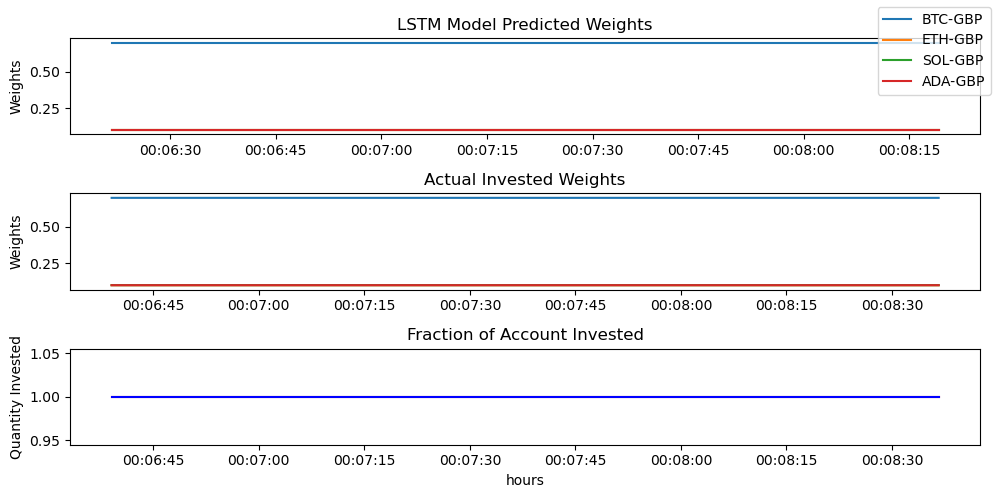

In [22]:
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = (10, 5))

index_p = w_p.index 
index_a = w_a.index

ax[0].set_title('LSTM Model Predicted Weights')
ax[0].plot(index_p, w_p_ary, label = tickers)
ax[0].set_ylabel('Weights')

ax[1].set_title('Actual Invested Weights')
ax[1].plot(index_a, w_a_ary)
ax[1].set_ylabel('Weights')

# invested quantity 
w_p_inv = np.sum(w_a_ary, axis = 1)
w_a_inv = np.sum(w_a_ary, axis = 1)
ax[2].set_title('Fraction of Account Invested')
ax[2].plot(index_a, w_p_inv.round(2), color = 'red')
ax[2].plot(index_a, w_a_inv.round(2), color = 'blue')
ax[2].set_ylabel('Quantity Invested')
ax[2].set_xlabel('hours')

fig.legend()
plt.tight_layout();

get distribution of predicted weights

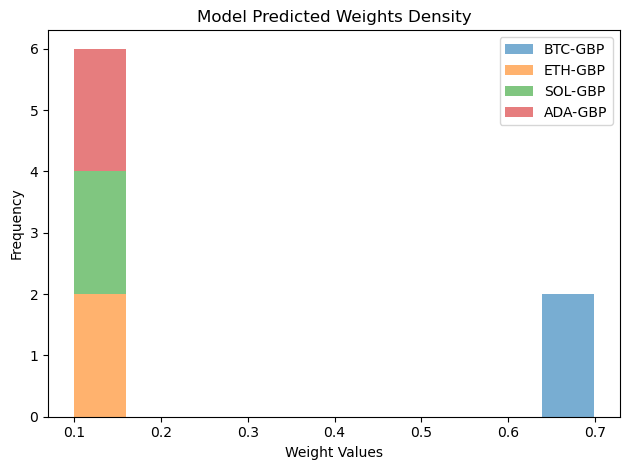

In [27]:
plt.title('Model Predicted Weights Density')
plt.hist(w_a_ary, histtype = 'barstacked', alpha = 0.6, label = tickers)
plt.ylabel('Frequency')
plt.xlabel('Weight Values')
plt.legend()
plt.tight_layout();

## Unit Test Weights

In [29]:
unit_test = CheckWeights()

# test 
tol = 1e-2
unit_test.check_weights(w_p_ary, w_a_ary, tol) 
print('no errors, portfolio is being rebalanced correctly')

# example of fail
a = np.array([123, 455])
b = a + tol*2 
#unit_test.check_weights(a, b)
#print('no erros')

no errors, order portfolio is being rebalanced correctley
